In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc

In [2]:
# 학습 데이터
train = [[2, 0], [4, 0], [6, 0], [8, 1], [10, 1], [12, 1], [14, 1]]
trainX = [[i[0]] for i in train]
trainy = [i[1] for i in train]

In [3]:
# 모델 훈련
model = LogisticRegression(solver='lbfgs')
model.fit(trainX, trainy)

LogisticRegression()

In [4]:
# 테스트 데이터
test = [[9, 0], [30, 1], [17, 1], [2, 0], [40, 1]]
testX = [[i[0]] for i in test]
testy = [i[1] for i in test]

In [5]:
# 예측
lr_probs = model.predict_proba(testX)
yhat = model.predict(testX)
print('실제:', testy)
print('예측:', yhat)
print('accuracy:', model.score(testX, testy))
print('예측(값):\n', np.round(lr_probs, 3))

실제: [0, 1, 1, 0, 1]
예측: [1 1 1 0 1]
accuracy: 0.8
예측(값):
 [[0.127 0.873]
 [0.    1.   ]
 [0.    1.   ]
 [0.992 0.008]
 [0.    1.   ]]


TPR: [0.    0.333 1.    1.   ]
FPR: [0. 0. 0. 1.]
threshold: [  inf 1.    1.    0.008]
ROC AUC: 1.000


Text(0, 0.5, 'True Positive Rate')

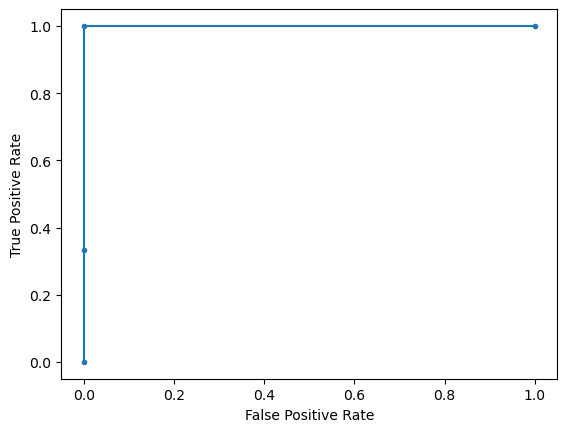

In [6]:
# 포지티브 출력에 대한 확률만 저장
lr_probs = lr_probs[:, 1]

# ROC 곡선
lr_fpr, lr_tpr, ths = roc_curve(testy, lr_probs)
print('TPR:', np.round(lr_tpr, 3))
print('FPR:', np.round(lr_fpr, 3))
print('threshold:', np.round(ths, 3))
lr_auc = roc_auc_score(testy, lr_probs)
print('ROC AUC: %.3f' % (lr_auc))

plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

Precision: [0.6  0.75 1.   1.   1.   1.  ]
Recall: [1.    1.    1.    0.667 0.333 0.   ]
threshold: [0.008 0.873 1.    1.    1.   ]
F1 socre: 0.857
PR AUC: 1.000


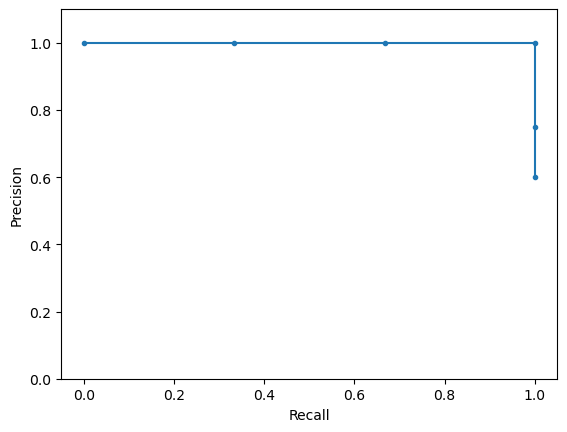

In [7]:
# precision-recall 곡선
lr_prec, lr_recall, ths = precision_recall_curve(testy, lr_probs)
print('Precision:', np.round(lr_prec, 3))
print('Recall:', np.round(lr_recall, 3))
print('threshold:', np.round(ths, 3))
#print('Precision:', lr_prec)
#print('Recall:', lr_recall)
#print('threshold:', ths)
lr_f1 = f1_score(testy, yhat)
print('F1 socre: %.3f' % (lr_f1))
lr_auc = auc(lr_recall, lr_prec)
print('PR AUC: %.3f' % (lr_auc))

plt.figure()
plt.plot(lr_recall, lr_prec, marker='.', label='Logistic')
plt.ylim(.0, 1.1)
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

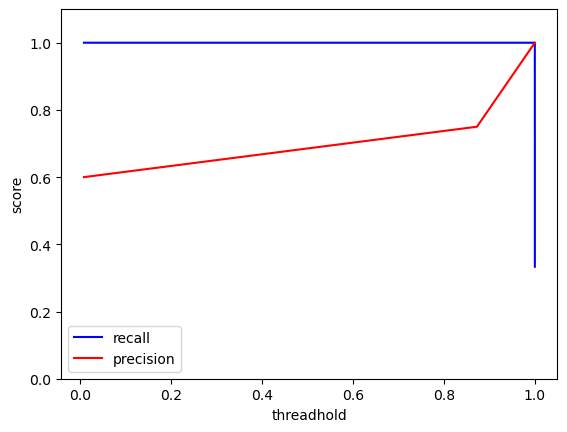

In [8]:
plt.figure()
plt.plot(ths, lr_recall[:len(ths)], color='b', label='recall')
plt.plot(ths, lr_prec[:len(ths)], color='r', label='precision')
plt.ylim(.0, 1.1)

plt.xlabel('threadhold') #임계값
plt.ylabel('score')

plt.legend()
plt.show()